In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


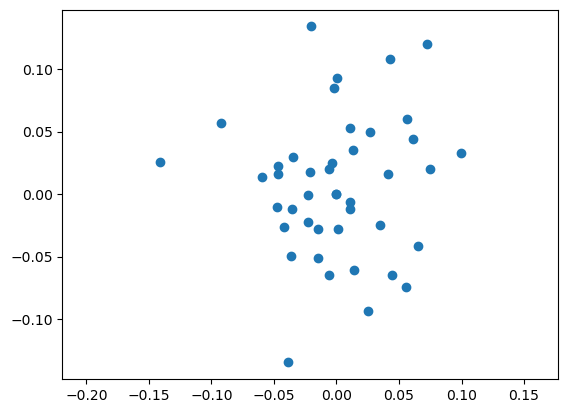

In [36]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=43,  # 轨迹的控制点数量 16
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.05
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.05

plt.scatter(xs, ys)
plt.axis('equal')
pass

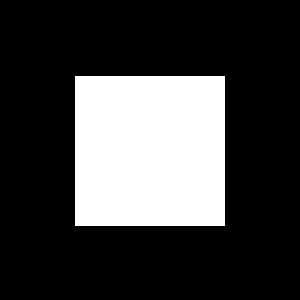

In [2]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

normal_0 = ti.Vector([1., 0.])
normal_1 = ti.Vector([0., 1.])
normal_2 = ti.Vector([-1., 0.])
normal_3 = ti.Vector([0., -1.])
edge_distance = 0.5
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return ti.math.dot(v, normal_0) < edge_distance and ti.math.dot(v, normal_1) < edge_distance and ti.math.dot(v, normal_2) < edge_distance and ti.math.dot(v, normal_3) < edge_distance  # 正方形内是墙

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [107]:
xs, ys, rotations = np.load('../trajectory/能让正方形旋转一周的房间_4/sofa_900.npy')

(-0.18798735579773537,
 0.18786431030807943,
 -0.18787566744269327,
 0.18770684700916024)

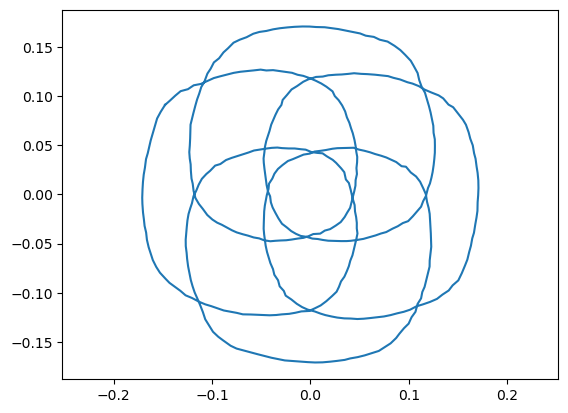

In [103]:
plt.plot(xs, ys)
plt.axis('equal')

In [96]:
len(xs)

512

In [92]:
sofa_w, sofa_h = 1.7, 1.7   # 求解域的尺寸

Initial survivors: 1.4558343887329102
iter 500 / 20000, maximal_area=1.4558371305465698
iter 1000 / 20000, maximal_area=1.4558426141738892
iter 1500 / 20000, maximal_area=1.455864667892456
iter 2000 / 20000, maximal_area=1.4558675289154053
iter 2500 / 20000, maximal_area=1.455870270729065
iter 3000 / 20000, maximal_area=1.4558730125427246
iter 3500 / 20000, maximal_area=1.4558730125427246
iter 4000 / 20000, maximal_area=1.4558757543563843
iter 4500 / 20000, maximal_area=1.4558812379837036
iter 5000 / 20000, maximal_area=1.4558839797973633
iter 5500 / 20000, maximal_area=1.4558894634246826
iter 6000 / 20000, maximal_area=1.4558950662612915
iter 6500 / 20000, maximal_area=1.4559005498886108
iter 7000 / 20000, maximal_area=1.4559088945388794
iter 7500 / 20000, maximal_area=1.4559088945388794
iter 8000 / 20000, maximal_area=1.4559115171432495
iter 8500 / 20000, maximal_area=1.4559197425842285
iter 9000 / 20000, maximal_area=1.4559197425842285
iter 9500 / 20000, maximal_area=1.4559197425842

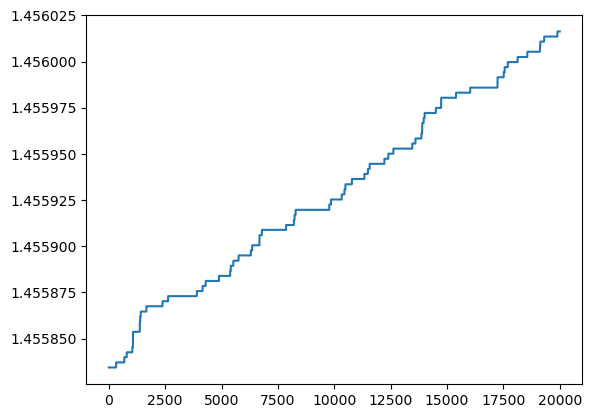

In [104]:
best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    ys,
    rotations,
    # initial_xs=zoom(xs, zoom=2, order=1),  # 保持轨迹分辨率时注释掉这三行
    # initial_ys=zoom(ys, zoom=2, order=1),
    # initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率
    iterations = 20000,  # 10000
    trajectory_upsampling=21,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让正方形旋转一周的房间_2/sofa_',
    save_image_start_id=1100,  # 文件起始标号
    save_trajectory_path='../trajectory/能让正方形旋转一周的房间_2/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [108]:
from utils import get_area

best_score = get_area(is_forbidden, xs, ys, rotations, sofa_w, sofa_h, resolution=5000, trajectory_upsampling=200)  # 以很高的分辨率计算面积

area = sofa_w * sofa_h - best_score  # 房间面积
area_disk = np.pi / 2  # 圆的面积
area / area_disk
print(f'相对于外接圆：{area} / {area_disk} = {area / area_disk}')
print(f'相对于五次旋转对称的解：{area} / {1.4349467897415158} = {area / 1.4349467897415158}')

相对于外接圆：1.4643591785430905 / 1.5707963267948966 = 0.9322400069084807
相对于五次旋转对称的解：1.4643591785430905 / 1.4349467897415158 = 1.02049719823191


五次旋转对称的解：1.4795262813568115 / 1.5707963267948966 = 0.9418956844492274

In [34]:
0.9477352776235347 / 0.9418956844492274

1.0061998300562571